In [1]:
### 05 — Subgroup Performance Evaluation
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    confusion_matrix
)

from xgboost import XGBClassifier

In [2]:
DATA_PATH = Path(
    "data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
)

df = pd.read_csv(DATA_PATH)

print(df.shape)

(70692, 22)


In [3]:
########recreate the exact same train/test split:
TARGET = "Diabetes_binary"
RANDOM_STATE = 42

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape)
print("Test:", X_test.shape)

Training: (56553, 21)
Test: (14139, 21)


In [4]:
###recreate the same final tuned XGBoost model:
final_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
    n_jobs=-1
)

final_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [5]:
y_prob = final_model.predict_proba(X_test)[:, 1]
y_pred = final_model.predict(X_test)

overall_auc = roc_auc_score(y_test, y_prob)

print("Overall test ROC-AUC:", round(overall_auc, 4))

Overall test ROC-AUC: 0.831


In [6]:
def subgroup_metrics(X_sub, y_sub):
    y_prob_sub = final_model.predict_proba(X_sub)[:, 1]
    y_pred_sub = final_model.predict(X_sub)

    tn, fp, fn, tp = confusion_matrix(
        y_sub,
        y_pred_sub,
        labels=[0, 1]
    ).ravel()

    specificity = tn / (tn + fp)

    if y_sub.nunique() == 2:
        auc = roc_auc_score(y_sub, y_prob_sub)
    else:
        auc = np.nan

    return {
        "n": len(y_sub),
        "ROC_AUC": auc,
        "Recall": recall_score(y_sub, y_pred_sub),
        "Specificity": specificity,
        "F1": f1_score(y_sub, y_pred_sub)
    }

In [10]:
###evaluate Sex:
sex_results = []

for group in sorted(X_test["Sex"].unique()):
    mask = X_test["Sex"] == group

    metrics = subgroup_metrics(
        X_test.loc[mask],
        y_test.loc[mask]
    )

    metrics["Sex"] = group
    sex_results.append(metrics)

sex_df = pd.DataFrame(sex_results)

sex_df[
    ["Sex", "n", "ROC_AUC", "Recall", "Specificity", "F1"]
].round(4)
sex_df["Sex"] = sex_df["Sex"].map({
    0.0: "Female",
    1.0: "Male"
})

sex_df[
    ["Sex", "n", "ROC_AUC", "Recall", "Specificity", "F1"]
].round(4)

,Sex,n,ROC_AUC,Recall,Specificity,F1
0,Female,7675,0.8418,0.7916,0.7364,0.7630
1,Male,6464,0.8171,0.8062,0.6739,0.7658


In [8]:
##evaluate age
age_results = []

for group in sorted(X_test["Age"].unique()):
    mask = X_test["Age"] == group

    metrics = subgroup_metrics(
        X_test.loc[mask],
        y_test.loc[mask]
    )

    metrics["Age"] = group
    age_results.append(metrics)

age_df = pd.DataFrame(age_results)

age_df[
    ["Age", "n", "ROC_AUC", "Recall", "Specificity", "F1"]
].round(4)

,Age,n,ROC_AUC,Recall,Specificity,F1
0,1.0,181,0.8762,0.0000,0.9943,0.0000
1,2.0,282,0.8343,0.1852,0.9882,0.2857
2,3.0,448,0.8366,0.4478,0.9580,0.5310
3,4.0,575,0.8557,0.4437,0.9151,0.5276
4,5.0,671,0.8372,0.6028,0.8621,0.6355
5,6.0,913,0.8377,0.6530,0.8238,0.6582
6,7.0,1361,0.8259,0.7408,0.7667,0.7268
7,8.0,1720,0.8279,0.7757,0.7400,0.7652
8,9.0,2032,0.8184,0.8278,0.6408,0.7859
9,10.0,2216,0.8012,0.8565,0.5876,0.8039


In [9]:
###evaluate income
income_results = []

for group in sorted(X_test["Income"].unique()):
    mask = X_test["Income"] == group

    metrics = subgroup_metrics(
        X_test.loc[mask],
        y_test.loc[mask]
    )

    metrics["Income"] = group
    income_results.append(metrics)

income_df = pd.DataFrame(income_results)

income_df[
    ["Income", "n", "ROC_AUC", "Recall", "Specificity", "F1"]
].round(4)

,Income,n,ROC_AUC,Recall,Specificity,F1
0,1.0,727,0.7924,0.9059,0.4889,0.8206
1,2.0,913,0.7600,0.9198,0.4264,0.8539
2,3.0,1117,0.7753,0.8668,0.5302,0.8216
3,4.0,1339,0.7887,0.8606,0.5272,0.7987
4,5.0,1599,0.7903,0.8263,0.6049,0.7741
5,6.0,2097,0.8115,0.7841,0.6817,0.7523
6,7.0,2208,0.8253,0.7679,0.7358,0.7375
7,8.0,4139,0.8497,0.6523,0.8431,0.6679


In [11]:
#### Bootstrap Confidence Intervals
def bootstrap_metric_ci(
    X_sub,
    y_sub,
    metric_name,
    n_bootstrap=1000,
    random_state=42
):
    rng = np.random.default_rng(random_state)
    values = []

    X_sub = X_sub.reset_index(drop=True)
    y_sub = y_sub.reset_index(drop=True)

    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_sub), len(y_sub))

        X_boot = X_sub.iloc[idx]
        y_boot = y_sub.iloc[idx]

        # Need both classes for ROC-AUC
        if metric_name == "ROC_AUC" and y_boot.nunique() < 2:
            continue

        y_prob_boot = final_model.predict_proba(X_boot)[:, 1]
        y_pred_boot = final_model.predict(X_boot)

        if metric_name == "ROC_AUC":
            value = roc_auc_score(y_boot, y_prob_boot)

        elif metric_name == "Recall":
            value = recall_score(y_boot, y_pred_boot)

        elif metric_name == "F1":
            value = f1_score(y_boot, y_pred_boot)

        elif metric_name == "Specificity":
            tn, fp, fn, tp = confusion_matrix(
                y_boot,
                y_pred_boot,
                labels=[0, 1]
            ).ravel()

            value = tn / (tn + fp)

        values.append(value)

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    return lower, upper

In [13]:
sex_ci_results = []

for group in sorted(X_test["Sex"].unique()):
    mask = X_test["Sex"] == group

    X_sub = X_test.loc[mask]
    y_sub = y_test.loc[mask]

    # Point estimate
    y_prob_sub = final_model.predict_proba(X_sub)[:, 1]
    auc = roc_auc_score(y_sub, y_prob_sub)

    # Bootstrap CI
    lower, upper = bootstrap_metric_ci(
        X_sub,
        y_sub,
        metric_name="ROC_AUC"
    )

    sex_ci_results.append({
        "Sex": "Female" if group == 0.0 else "Male",
        "n": len(y_sub),
        "ROC_AUC": auc,
        "CI_lower": lower,
        "CI_upper": upper
    })

sex_ci_df = pd.DataFrame(sex_ci_results)

sex_ci_df.round(4)

,Sex,n,ROC_AUC,CI_lower,CI_upper
0,Female,7675,0.8418,0.8327,0.8499
1,Male,6464,0.8171,0.8066,0.8273


In [14]:
####ROC-AUC + 95% bootstrap CI for Age and Income
def subgroup_auc_ci_table(group_col):
    results = []

    for group in sorted(X_test[group_col].unique()):
        mask = X_test[group_col] == group

        X_sub = X_test.loc[mask]
        y_sub = y_test.loc[mask]

        y_prob_sub = final_model.predict_proba(X_sub)[:, 1]

        auc = roc_auc_score(y_sub, y_prob_sub)

        lower, upper = bootstrap_metric_ci(
            X_sub,
            y_sub,
            metric_name="ROC_AUC"
        )

        results.append({
            group_col: group,
            "n": len(y_sub),
            "ROC_AUC": auc,
            "CI_lower": lower,
            "CI_upper": upper
        })

    return pd.DataFrame(results)

In [15]:
age_ci_df = subgroup_auc_ci_table("Age")
age_ci_df.round(4)

,Age,n,ROC_AUC,CI_lower,CI_upper
0,1.0,181,0.8762,0.7709,0.9609
1,2.0,282,0.8343,0.7455,0.9152
2,3.0,448,0.8366,0.7838,0.8848
3,4.0,575,0.8557,0.8246,0.8851
4,5.0,671,0.8372,0.8055,0.8675
5,6.0,913,0.8377,0.8118,0.8625
6,7.0,1361,0.8259,0.8047,0.8492
7,8.0,1720,0.8279,0.8069,0.8482
8,9.0,2032,0.8184,0.7983,0.8364
9,10.0,2216,0.8012,0.7808,0.8201


In [16]:
income_ci_df = subgroup_auc_ci_table("Income")
income_ci_df.round(4)

,Income,n,ROC_AUC,CI_lower,CI_upper
0,1.0,727,0.7924,0.7578,0.8239
1,2.0,913,0.7600,0.7259,0.7940
2,3.0,1117,0.7753,0.7469,0.8050
3,4.0,1339,0.7887,0.7619,0.8124
4,5.0,1599,0.7903,0.7668,0.8138
5,6.0,2097,0.8115,0.7934,0.8291
6,7.0,2208,0.8253,0.8082,0.8420
7,8.0,4139,0.8497,0.8375,0.8606


In [17]:
age_labels = {
    1.0: "18–24",
    2.0: "25–29",
    3.0: "30–34",
    4.0: "35–39",
    5.0: "40–44",
    6.0: "45–49",
    7.0: "50–54",
    8.0: "55–59",
    9.0: "60–64",
    10.0: "65–69",
    11.0: "70–74",
    12.0: "75–79",
    13.0: "80+"
}

income_labels = {
    1.0: "<$10k",
    2.0: "$10–<15k",
    3.0: "$15–<20k",
    4.0: "$20–<25k",
    5.0: "$25–<35k",
    6.0: "$35–<50k",
    7.0: "$50–<75k",
    8.0: "$75k+"
}

In [18]:
age_plot_df = age_ci_df.copy()
age_plot_df["Group"] = age_plot_df["Age"].map(age_labels)

income_plot_df = income_ci_df.copy()
income_plot_df["Group"] = income_plot_df["Income"].map(income_labels)

sex_plot_df = sex_ci_df.copy()
sex_plot_df["Group"] = sex_plot_df["Sex"]

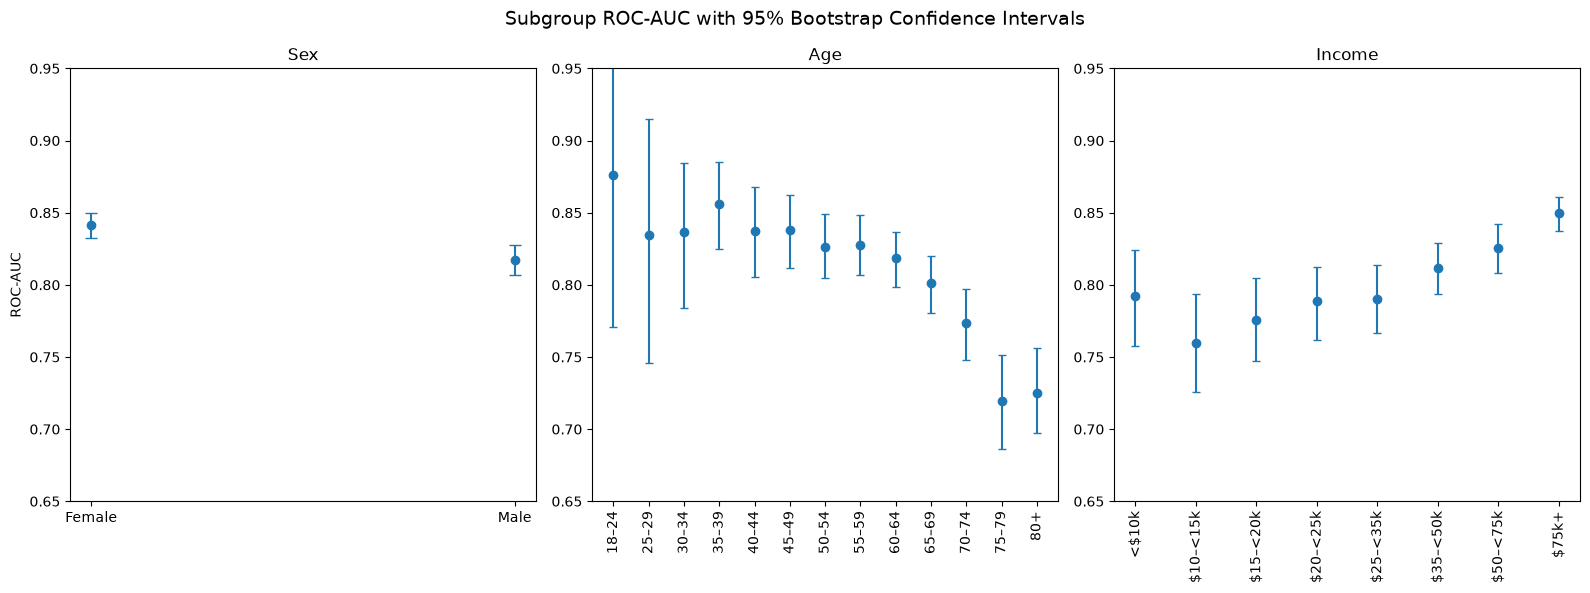

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Sex
axes[0].errorbar(
    sex_plot_df["Group"],
    sex_plot_df["ROC_AUC"],
    yerr=[
        sex_plot_df["ROC_AUC"] - sex_plot_df["CI_lower"],
        sex_plot_df["CI_upper"] - sex_plot_df["ROC_AUC"]
    ],
    fmt="o",
    capsize=4
)
axes[0].set_title("Sex")
axes[0].set_ylabel("ROC-AUC")
axes[0].set_ylim(0.65, 0.95)

# Age
axes[1].errorbar(
    age_plot_df["Group"],
    age_plot_df["ROC_AUC"],
    yerr=[
        age_plot_df["ROC_AUC"] - age_plot_df["CI_lower"],
        age_plot_df["CI_upper"] - age_plot_df["ROC_AUC"]
    ],
    fmt="o",
    capsize=3
)
axes[1].set_title("Age")
axes[1].set_ylim(0.65, 0.95)
axes[1].tick_params(axis="x", rotation=90)

# Income
axes[2].errorbar(
    income_plot_df["Group"],
    income_plot_df["ROC_AUC"],
    yerr=[
        income_plot_df["ROC_AUC"] - income_plot_df["CI_lower"],
        income_plot_df["CI_upper"] - income_plot_df["ROC_AUC"]
    ],
    fmt="o",
    capsize=3
)
axes[2].set_title("Income")
axes[2].set_ylim(0.65, 0.95)
axes[2].tick_params(axis="x", rotation=90)

fig.suptitle(
    "Subgroup ROC-AUC with 95% Bootstrap Confidence Intervals",
    fontsize=14
)

plt.tight_layout()
plt.show()

In [20]:
# Create subgroup tables

sex_table = sex_df[
    ["Sex", "n", "Recall", "Specificity", "F1"]
].copy()

sex_table = sex_table.rename(columns={"Sex": "Group"})
sex_table.insert(0, "Subgroup", "Sex")


age_table = age_df[
    ["Age", "n", "Recall", "Specificity", "F1"]
].copy()

age_table["Age"] = age_table["Age"].map(age_labels)
age_table = age_table.rename(columns={"Age": "Group"})
age_table.insert(0, "Subgroup", "Age")


income_table = income_df[
    ["Income", "n", "Recall", "Specificity", "F1"]
].copy()

income_table["Income"] = income_table["Income"].map(income_labels)
income_table = income_table.rename(columns={"Income": "Group"})
income_table.insert(0, "Subgroup", "Income")

In [21]:
subgroup_performance_table = pd.concat(
    [sex_table, age_table, income_table],
    ignore_index=True
)

subgroup_performance_table[
    ["Recall", "Specificity", "F1"]
] = subgroup_performance_table[
    ["Recall", "Specificity", "F1"]
].round(4)

subgroup_performance_table

,Subgroup,Group,n,Recall,Specificity,F1
0,Sex,Female,7675,0.7916,0.7364,0.7630
1,Sex,Male,6464,0.8062,0.6739,0.7658
2,Age,18–24,181,0.0000,0.9943,0.0000
3,Age,25–29,282,0.1852,0.9882,0.2857
4,Age,30–34,448,0.4478,0.9580,0.5310
5,Age,35–39,575,0.4437,0.9151,0.5276
6,Age,40–44,671,0.6028,0.8621,0.6355
7,Age,45–49,913,0.6530,0.8238,0.6582
8,Age,50–54,1361,0.7408,0.7667,0.7268
9,Age,55–59,1720,0.7757,0.7400,0.7652


In [ ]:
###Subgroup Evaluation Summary. The selected XGBoost model showed non-uniform performance across sex, age and income groups. Sex differences were modest, whereas age and income showed stronger variation in discrimination and threshold-dependent performance. Younger age groups had wider uncertainty, while older age groups generally showed lower ROC-AUC. Income groups showed increasing discrimination at higher income levels. These findings indicate subgroup performance variation and should not be interpreted as a formal fairness assessment.